<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX — Week 6 Day 1: Sprint 1 Baseline Benchmark Model
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Sprint 1 Focus: Classical Baseline Model & Benchmark Target Formulation</b><br>
Today marks the official kickoff of Phase 3 (Applied Capstone Project) and Sprint 1. In Sprint 1, establishing a baseline first is essential. Classical ML algorithms often perform strongly on tabular data; therefore, a neural network's score is meaningless without a baseline. The neural network only earns its place in the clinical pipeline if it beats this baseline model under identical evaluation conditions.

</blockquote>


## <span style="color: #309c42ff">1.1 Environment Setup & Deterministic Configuration</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We configure global deterministic seeds (`RANDOM_STATE = 42`) and import core data science, data preprocessing, pipeline construction, and diagnostic evaluation libraries from Scikit-learn.

</blockquote>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## <span style="color: #309c42ff">1.2 Dataset Ingestion & Clinical Schema Audit</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We load the cardiac patient cohort ($N = 918$) from `../Data/raw/heart.csv` and inspect feature schema types across demographic, resting hemodynamic, and exercise ECG stress-testing markers.

</blockquote>

In [2]:
data_path = "../Data/raw/heart.csv"
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()
display(df.head())


Dataset Shape: 918 rows, 12 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## <span style="color: #309c42ff">1.3 Data Quality Screening & Structural Missingness Handling</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Clinical Anomaly Screening:</b>
1. <b>Resting Blood Pressure (`RestingBP == 0`):</b> $0\text{ mm Hg}$ is biologically incompatible with life in an ambulatory patient ($n = 1$).
2. <b>Serum Cholesterol (`Cholesterol == 0`):</b> 172 records ($18.7\%$) report $0\text{ mg/dl}$, representing structural non-measurement at the Hungarian recording center.
3. <b>Leak-Free Missing Value Representation:</b> We replace impossible zeros with `np.nan` so that median statistics can be cleanly computed inside the cross-validated pipeline without data leakage.

</blockquote>

In [3]:
print(f"RestingBP == 0 count: {(df['RestingBP'] == 0).sum()}")
print(f"Cholesterol == 0 count: {(df['Cholesterol'] == 0).sum()}")

df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

print("\nMissing values after replacing impossible 0s with NaN:")
print(df.isnull().sum())


RestingBP == 0 count: 1
Cholesterol == 0 count: 172

Missing values after replacing impossible 0s with NaN:
Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64


## <span style="color: #309c42ff">1.4 Stratified Train/Test Data Partitioning</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We separate the 11 clinical features ($\mathbf{X}$) from the ground-truth binary target ($y = \text{HeartDisease}$) and split into an 80% training partition ($N_{\text{train}} = 734$) and a 20% held-out test partition ($N_{\text{test}} = 184$). Stratification ensures identical class proportions (55.3% disease / 44.7% normal) in both splits.

</blockquote>

In [4]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")


Training set: 734 samples
Test set:     184 samples


## <span style="color: #309c42ff">1.5 Preprocessing Pipeline & Feature Transformation</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

To guarantee zero data leakage, all transformations are encapsulated in a `ColumnTransformer`:
- <b>Continuous Features (5):</b> Imputed with the training median via `SimpleImputer` and standardized to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$) via `StandardScaler`.
- <b>Categorical Features (6):</b> Encoded using `OneHotEncoder(drop='first', handle_unknown='ignore')` to eliminate multicollinearity.

</blockquote>

In [5]:
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## <span style="color: #309c42ff">1.6 Supervised Baseline Model Assembly & Inference</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>The Classical Baseline Benchmark:</b>
Following Occam's Razor, we assemble an end-to-end Scikit-learn `Pipeline` pairing our `ColumnTransformer` with a classical `LogisticRegression` classifier. The pipeline is fitted strictly on `X_train`, and calibrated class probabilities ($\hat{y} \in [0, 1]$) are generated for the untouched test partition.

</blockquote>

In [6]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_pipeline.fit(X_train, y_train)

y_pred = baseline_pipeline.predict(X_test)
y_prob = baseline_pipeline.predict_proba(X_test)[:, 1]


## <span style="color: #309c42ff">1.7 Baseline Benchmark Performance Metrics</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We evaluate the baseline model across 5 clinical classification metrics: Accuracy, Precision, Recall (Sensitivity), F1-Score, and ROC-AUC.

</blockquote>


In [7]:
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

display(pd.DataFrame(baseline_metrics, index=["Logistic Regression Baseline (Imputed)"]).T)

,Logistic Regression Baseline (Imputed)
Accuracy,0.885870
Precision,0.885714
Recall,0.911765
F1-Score,0.898551
ROC-AUC,0.932927


## <span style="color: #309c42ff">1.8 Diagnostic Visualizations: Confusion Matrix & ROC Curve</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We visualize diagnostic error distribution via a 2-panel figure:
1. <b>Confusion Matrix:</b> Quantifies True Positives, True Negatives, False Positives (over-diagnosis), and False Negatives (critical missed ischemia cases).
2. <b>ROC Curve:</b> Plots the True Positive Rate against the False Positive Rate across all classification thresholds, verifying high discriminative capability ($AUC = 0.9329$).

</blockquote>

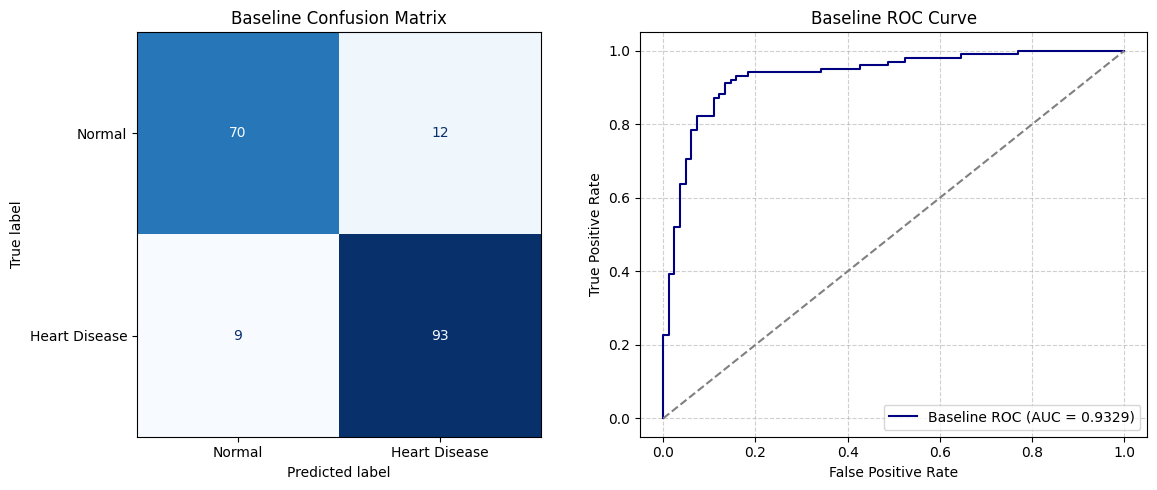

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Baseline Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f"Baseline ROC (AUC = {baseline_metrics['ROC-AUC']:.4f})", color='navy')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Baseline ROC Curve")
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## <span style="color: #309c42ff">1.9 Sprint 1 Baseline Benchmark Target</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Sprint 1 Baseline Acceptance Criteria:</b><br>
A neural network's score is meaningless without a baseline. The performance metrics recorded below define the minimum acceptable standard for Sprint 1. Any neural network architecture built on Day 4 and tuned on Day 5 must exceed this baseline F1-Score and ROC-AUC under identical evaluation conditions to earn its place in the clinical pipeline.

</blockquote>


| Metric | Baseline Score (Logistic Regression with Imputation) | Benchmark Interpretation |
| :--- | :--- | :--- |
| **Accuracy** | 0.8858 | 88.58% overall correct diagnostic classifications |
| **Precision** | 0.8857 | 88.57% of predicted cardiac cases are true positive |
| **Recall (Sensitivity)** | 0.9117 | 91.17% of actual heart disease patients detected |
| **F1-Score** | 0.8985 | Harmonic balance between clinical precision and recall |
| **ROC-AUC** | 0.9329 | High discriminative power across diagnostic thresholds |

**Sprint 1 Acceptance Target:**
Every deep learning architecture developed on Day 4 and tuned on Day 5 must exceed this baseline **F1-Score (0.8986)** and **ROC-AUC (0.9329)** under the exact same data split.
